# Multi-Model Switching with Contact

**RQ2 handover.** What does the state transfer cost when the two models use
different representations?

Three backends behind one interface — FEM, OpenSim, and an FMU — switched by an
ordered region map on the pendulum angle, against a monolithic OpenModelica
reference. This is the notebook that measures the handover itself: every
committed transfer carries a report, and the quantities that the canonical
interface does *not* carry are the ones that price it.

In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().resolve()))
from evidence import repo_root

REPO = repo_root()

import evidence as ev
from plot_setup import FULL_WIDTH, set_professional_style
from record import record, paper_results_dir

plt = set_professional_style(latex=True)

# Recorded numbers belong to the paper repository, not to this one.
RESULTS, _results_source = paper_results_dir(REPO)
print(f"repository root resolved: {REPO.name}")
print(f"results destination      : {_results_source}")

In [ ]:
# Pin the OpenModelica toolchain. OMPython resolves omc through OPENMODELICAHOME
# and PATH, so a second installation silently changes which compiler builds the
# reference - and therefore the trajectory every error below is measured against.
import os

OM_VERSION_EXPECTED = "1.26.3"
OM_HOME = Path(os.environ.get("SYSSIMX_OM_HOME", r"C:\Program Files\OpenModelica1.26.3-64bit"))
if next((c for c in (OM_HOME / "bin/omc.exe", OM_HOME / "bin/omc") if c.is_file()), None) is None:
    raise FileNotFoundError(f"No OpenModelica compiler under {OM_HOME}. Set SYSSIMX_OM_HOME.")
os.environ["OPENMODELICAHOME"] = str(OM_HOME)

from OMPython import OMCSessionZMQ

om_version = OMCSessionZMQ().sendExpression("getVersion()")
print(f"OpenModelica : {om_version}")
if OM_VERSION_EXPECTED not in om_version:
    raise RuntimeError(
        f"Expected OpenModelica {OM_VERSION_EXPECTED}, got {om_version}. The reference is only "
        f"comparable within one toolchain: set SYSSIMX_OM_HOME and OM_VERSION_EXPECTED together."
    )

## Configuration

The scenario is the shared contact configuration. The launch gate is what keeps
the expensive deformable model out of the window where the pendulum is
accelerating away from the wall and cannot contact anything.

The region key is `|theta|`, which cannot tell approach from recession: the same
angle occurs on the way out and on the way back, and only the approach needs the
deformable model. The gate is the declared stand-in for that distinction over
the launch window. It is sized so the run starts in the FMU plant and the first
switch comes from the swing rather than from the ramp expiring.

In [ ]:
HORIZON_S = 1.0

# Launch gate. The pendulum starts at the wall and accelerates away from it,
# so |theta| is inside the FEM region while contact is impossible. The gate
# lifts the region key over that window and hands back to the physical signal
# once |theta| has risen on its own, which is what lets the run start in the
# cheapest model and still reach FEM by the descent.
#
# Sized against the measured FMU trajectory, not guessed. |theta| first reaches
# the FMU lower active threshold (0.2618 - 0.01745 = 0.24435) at t = 0.047 s and
# peaks at 0.358 rad near t = 0.085 s. A ramp of 0.06 s with a 0.30 rad offset
# keeps the key at or above 0.256 for the whole ramp, a margin of about
# 0.012 rad over the threshold, and hands over continuously at |theta| = 0.319.
# A shorter ramp expires while |theta| is still below the threshold and produces
# the FMU -> OpenSim -> FMU pair inside the ramp that 5be19a2 removed.
# Run policy. One NGSolve thread makes the FEM bit-identical on repetition
# (06_determinism), so one run is the measurement and repeating it adds nothing.
# Any other thread count is not reproducible, and a single run is then one draw;
# the run cell refuses that combination instead of recording it.
NGSOLVE_THREADS = 1

N_REPEATS = 1

# Contact diagnostics, off for campaign runs. When on, the hybrid algorithm logs
# every detection and localization at DEBUG level to notebooks/diagnostics/, and
# every wall_hit dispatch records the plant angle, velocity and FEM contact gap.
# The log is gitignored, so it never dirties the measured surface. See HYB-08.
DIAGNOSE_CONTACTS = False

SCENARIO = ev.CONTACT_SCENARIO.replace(
    t_end=HORIZON_S, raise_on_missed_event=True,
    ngsolve_threads=NGSOLVE_THREADS, gate_offset_rad=0.30, gate_t_open_s=0.06,
)
# FEM region edges, in radians. The FEM region is entered below the lower edge
# and left above the upper one, so a whole contact episode has to fit under the
# upper edge. The entry edge stays at the packaged 0.070: a later entry (0.087,
# breakpoint 0.092) tripled the contact-time deviation from the rigid reference.
# The exit edge is raised from the packaged 0.080 to 0.100: at 0.080 the last
# rebound of the 1.0 s run (0.0797 rad) left FEM and came back within 10 ms.
# 0.100 is 1.25x the largest bounce. The bounce-envelope cell below reports the
# margin on every run. See HYB-09.
FEM_ENTER_RAD = 0.070
FEM_EXIT_RAD = 0.100
FEM_BREAKPOINT_RAD = 0.5 * (FEM_ENTER_RAD + FEM_EXIT_RAD)
FEM_BAND_RAD = 0.5 * (FEM_EXIT_RAD - FEM_ENTER_RAD)


OUT_DIR = REPO / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PACKAGE = REPO / "demos" / "ControlledPendulum" / "src" / "modelica" / "ControlledPendulum"
REFERENCE_MODEL = "ControlledPendulum.Examples.Contact.RigidContact"
FMU_PATHS = ev.discover_fmus(REPO, sys.platform)

display(pd.Series(SCENARIO.provenance()).to_frame("value"))

## Monolithic reference

In [ ]:
from OMPython import ModelicaSystem

reference = ModelicaSystem(
    fileName=str(PACKAGE / "package.mo"), modelName=REFERENCE_MODEL, omhome=str(OM_HOME)
)
reference.setParameters({"useReset": "true"})
reference.buildModel()
reference.simulate(simargs={"stopTime": SCENARIO.t_end,})

REF_SIGNALS = ("time", "theta", "theta_ref", "u_control", "pid.I_out", "pendulum.contact")
ref = {name: reference.getSolutions(name).flatten() for name in REF_SIGNALS}

# Reference contact instants are the *rising edges* of the contact flag, not
# every second sample of it: the flag stays high for the whole contact phase, so
# a fixed stride silently mislabels the events it pairs up.
flag = np.asarray(ref["pendulum.contact"]) > 0
edges = np.flatnonzero(np.diff(flag.astype(int)) == 1) + 1
ref_contact_times = ref["time"][edges]
ref_contact_times = ref_contact_times[ref_contact_times <= SCENARIO.t_end]
print(f"reference contacts within the horizon: {len(ref_contact_times)}")

## Plant

`MasterPendulum` builds all three backends and owns its region map. Only the
region *key* is overridden, to add the launch gate; the gate reads the active
sub-model's clock because `HybridAlgorithm` calls `_do_step_internal` directly
for trial steps and bisection, which never advances the wrapper's own `t`.

In [ ]:
from syssimx_examples.controlled_pendulum import (
    MasterPendulum,
    MasterPendulumSwitchConfig,
)

# The region map the run actually uses. Built here rather than taken from the
# packaged default so the FEM edges above are the single place that set it,
# and so the emitted result can record the map that ran.
SWITCH_CONFIG = MasterPendulumSwitchConfig(
    breakpoints=(FEM_BREAKPOINT_RAD, np.deg2rad(15.0)),
    bands=(FEM_BAND_RAD, np.deg2rad(1.0)),
)
REGION_MAP = {
    "breakpoints_rad": list(SWITCH_CONFIG.breakpoints),
    "bands_rad": list(SWITCH_CONFIG.bands),
    "modes": list(SWITCH_CONFIG.modes),
}

REGION_GATE = ev.TimeGatedRegionKey(
    offset=SCENARIO.gate_offset_rad, t_open=SCENARIO.gate_t_open_s
)


# --- contact diagnostics, HYB-08 ------------------------------------------
DIAG_LOG = REPO / "notebooks" / "diagnostics" / "03_switching_hybrid.log"
CONTACT_DISPATCHES = []

if DIAGNOSE_CONTACTS:
    import logging

    DIAG_LOG.parent.mkdir(parents=True, exist_ok=True)
    _hybrid_log = logging.getLogger("syssimx.system.algorithms.hybrid")
    # Re-running this cell must not stack handlers and duplicate every line.
    for _old in [h for h in _hybrid_log.handlers if getattr(h, "syx_diagnostic", False)]:
        _hybrid_log.removeHandler(_old)
        _old.close()
    _diag_handler = logging.FileHandler(DIAG_LOG, mode="w", encoding="utf-8")
    _diag_handler.syx_diagnostic = True
    _diag_handler.setLevel(logging.DEBUG)
    _diag_handler.setFormatter(logging.Formatter("%(message)s"))
    _hybrid_log.addHandler(_diag_handler)
    _hybrid_log.setLevel(logging.DEBUG)


def _as_float(value):
    return float(value) if value is not None else float("nan")


class GatedMasterPendulum(MasterPendulum):
    '''`MasterPendulum` whose region key is gated through the launch window.'''

    @staticmethod
    def _absolute_theta(component):
        return REGION_GATE(component)

    def _handle_events_internal(self, event_names, t):
        # Read-only snapshot of every wall_hit dispatch. It reads the gap values
        # the FEM stored after its last solve and never calls
        # _get_contact_gap_distance(), which updates the NGSolve contact set and
        # would perturb the run it is meant to observe.
        if DIAGNOSE_CONTACTS and "wall_hit" in event_names:
            outputs = self.get_outputs()
            CONTACT_DISPATCHES.append({
                "t": float(t),
                "events": ", ".join(event_names),
                "active_model": self.active_mode,
                "theta": float(ev.scalar_value(outputs["theta"])),
                "omega": float(ev.scalar_value(outputs["omega"])),
                "fem_gap": _as_float(getattr(self.fem, "gap", None)),
                "fem_gap_prev": _as_float(getattr(self.fem, "gap_prev", None)),
            })
        super()._handle_events_internal(event_names, t)


def run_once(label):
    """One complete switched run, returned as plain data.

    A fresh plant every time: repeated runs must not share state. Everything the
    tables below need is returned, because the system itself is not kept.
    """
    CONTACT_DISPATCHES.clear()
    plant = GatedMasterPendulum(
        name="MasterPendulum", initial_mode="FMU", switch_config=SWITCH_CONFIG
    )
    plant.record_switch_state = True
    plant.set_parameters(**{"FEM": ev.make_fem_parameters(SCENARIO)})
    system, plant = ev.assemble_system(
        plant, SCENARIO, FMU_PATHS, case_name="Multi-Model Switching"
    )
    initial_mode = plant.active_mode

    with tqdm(total=SCENARIO.sim_time, desc=label, unit=" sim s", leave=False) as bar:
        seen = SCENARIO.t0

        def advance(t_now, _t_final):
            nonlocal seen
            now = min(max(t_now, SCENARIO.t0), SCENARIO.t_end)
            bar.update(now - seen)
            seen = now

        system.run(SCENARIO.t0, SCENARIO.t_end, SCENARIO.macro_dt, progress=advance)

    history = system.get_history()
    t_plant, data_plant = history[plant.name]
    t_plant = np.asarray(t_plant, dtype=float)
    theta_plant = np.asarray(data_plant["theta"], dtype=float)
    contact_times = ev.contact_event_times(system, plant)

    transfers = pd.DataFrame([
        {
            "t": float(e.time), "from": e.from_mode, "to": e.to_mode,
            "d_theta": e.transfer_report.theta_error,
            "d_omega": e.transfer_report.omega_error,
            "d_tau": e.transfer_report.tau_error,
            "d_alpha": e.transfer_report.alpha_error,
            "d_energy": e.transfer_report.energy_error,
            "elastic_lost": e.transfer_report.elastic_energy_lost,
            "d_momentum": plant.rigid_properties.inertia * e.transfer_report.omega_error,
            "violations": ", ".join(
                e.transfer_report.violations(plant.transfer_tolerances)
            ) or "-",
        }
        for e in plant.switch_events
    ])

    abs_theta = np.abs(theta_plant)
    boundaries = plant.switch_regions.boundaries
    rows = []
    for (_comp, event_name), records in history["Events"].items():
        if not event_name.startswith("region_boundary_"):
            continue
        boundary = boundaries[int(event_name.rsplit("_", 1)[1])]
        for rec in records:
            t_event = float(rec.t)
            key = REGION_GATE.value(t_event, float(np.interp(t_event, t_plant, abs_theta)))
            armed = (boundary.upper_threshold if key >= boundary.breakpoint
                     else boundary.lower_threshold)
            committed = [e for e in plant.switch_events if abs(e.time - t_event) <= 1e-12]
            rows.append({
                "t": t_event, "boundary": event_name, "armed": armed, "key": key,
                "residual": key - armed,
                "off_grid": ev.distance_to_grid(t_event, SCENARIO.macro_dt),
                "switch": (f"{committed[0].from_mode} -> {committed[0].to_mode}"
                           if committed else "-"),
            })
    localization = pd.DataFrame(rows).sort_values("t").reset_index(drop=True)

    return {
        "plant": plant,
        "initial_mode": initial_mode,
        "t": t_plant,
        "theta": theta_plant,
        "omega": np.asarray(data_plant["omega"], dtype=float),
        "dispatches": list(CONTACT_DISPATCHES),
        "contact_times": contact_times,
        "contact_closures": ev.fem_contact_closures(plant),
        "transfers": transfers,
        "localization": localization,
        "intervals": ev.mode_intervals(
            plant.switch_events, initial_mode, SCENARIO.t0, SCENARIO.t_end
        ),
    }


## Run

In [ ]:
# CAMPAIGN selects whether the result is a campaign file or a smoke file. It no
# longer sets the repetition count: NGSOLVE_THREADS and N_REPEATS are set in the
# configuration cell. With one thread the run is bit-identical on repetition
# (06_determinism), so one run is the measurement. Repetitions carry information
# only when the FEM is threaded, and then five is the floor from
# evidence_plan.md section 6.

CAMPAIGN = True

In [ ]:
if SCENARIO.ngsolve_threads != 1 and N_REPEATS < 5:
    raise ValueError(
        f"ngsolve_threads={SCENARIO.ngsolve_threads} is not bit-reproducible, so "
        f"N_REPEATS={N_REPEATS} would record a single draw. Use one thread, or at "
        f"least five repetitions."
    )

repeats = [run_once(f"repeat {i + 1}/{N_REPEATS}") for i in range(N_REPEATS)]

# The first repetition is the representative one for the figures; it is not
# more correct than the others, only the one that gets drawn.
rep = repeats[0]
plant, intervals = rep["plant"], rep["intervals"]
t_plant, theta_plant = rep["t"], rep["theta"]
contact_times = rep["contact_times"]
initial_mode = rep["initial_mode"]

counts = pd.DataFrame([
    {"repeat": i + 1,
     "switches": len(r["transfers"]),
     "contacts": len(r["contact_times"]),
     "max_|residual|_rad": r["localization"]["residual"].abs().max(),
     "min_off_grid_s": r["localization"]["off_grid"].min()}
    for i, r in enumerate(repeats)
])
display(counts.style.format({
    "max_|residual|_rad": "{:.3e}", "min_off_grid_s": "{:.3e}"}).hide(axis="index"))

print(f"reconciled initial mode : {initial_mode}")

# The launch gate must select the starting model, not drive switches.
assert initial_mode == "FMU", f"expected to start in FMU, got {initial_mode}"
_gate_driven = [e for e in plant.switch_events if float(e.time) <= SCENARIO.gate_t_open_s]
assert not _gate_driven, (
    f"{len(_gate_driven)} switch(es) inside the {SCENARIO.gate_t_open_s} s launch ramp: "
    + ", ".join(f"{e.from_mode}->{e.to_mode}@{float(e.time):.4f}" for e in _gate_driven)
)
print(f"reference contacts      : {len(ref_contact_times)}")


## T1 — per-switch transfer report

Two groups of quantities, read differently.

`theta`, `omega` and `tau` are **enforced** invariants: the transaction raises
and rolls back when any of them jumps further than its tolerance, so a completed
run cannot show a violation. Their columns confirm the contract held; they are
not a measurement of handover quality.

`alpha` and the energy terms are **measured but not enforced**, because the
canonical interface carries angular position, velocity and torque only. Those are
the quantities that actually price a handover. `elastic_lost` is the strain
energy present in the FEM state and absent from the rigid target — the projection
loss of leaving the deformable model.

`d_momentum` sits with the **enforced** group, not with the free measurements.
Every backend is synchronized to one rigid parameter set, so angular momentum is
`J * omega` with a single `J` and its jump is exactly `J` times the enforced
`omega` residual. The column answers the conserved-quantity question asked in
`evidence_plan.md` section 4. It is not independent evidence for RQ2, and section
6.2 must not quote it beside `d_alpha` and the energy terms as though it were.

In [ ]:
# --- what survives repetition ----------------------------------------------
# The enforced invariants are bounded by the transaction: any completed run
# shows the contract held, so they confirm the contract and measure nothing.
# The free measurements - angular acceleration and the energy terms - are
# physics quantities that vary between identical runs under REPRO-02, so they
# are reported as a median over repetitions with the observed spread.

for i, r in enumerate(repeats):
    assert not (r["transfers"]["violations"] != "-").any(), (
        f"repeat {i + 1}: a transfer violated its declared tolerance"
    )
    # Every impact the FEM resolved on the committed trajectory must have been
    # dispatched. The coordinator's endpoint guard cannot see an episode
    # shorter than a macro step, so this is the check that catches a lost
    # contact (HYB-10).
    ev.check_contact_dispatch(r["plant"], r["contact_times"], label=f"repeat {i + 1}")
print(f"closures == dispatches  : {[r['contact_closures'] for r in repeats]}")

# Structural stability first. If the runs do not agree on how many switches and
# contacts occurred, no per-transfer aggregate is meaningful.
switch_counts = sorted({len(r["transfers"]) for r in repeats})
contact_counts = sorted({len(r["contact_times"]) for r in repeats})
print(f"switches across repeats : {switch_counts}")
print(f"contacts across repeats : {contact_counts}")
# D6, settled 2026-09-12: when the repetitions disagree, report the
# disagreement. Do not shorten the horizon and do not aggregate across different
# event sequences. This used to raise, which discarded a five-repetition run at
# the point D6 says is a result.
sequence_groups = {}
for i, r in enumerate(repeats):
    sequence_groups.setdefault(
        (len(r["transfers"]), len(r["contact_times"])), []
    ).append(i + 1)
repeats_agree = len(sequence_groups) == 1

if not repeats_agree:
    print("\nREPRO-02: the repetitions resolved different event sequences.")
    for (n_sw, n_ct), members in sorted(sequence_groups.items()):
        print(f"  {n_sw:3d} switches, {n_ct:3d} contacts : repeats {members}")
    # Aggregate only within the largest group that shares one sequence. Mixing
    # sequences would average handovers that are not the same handover.
    modal = max(sequence_groups.items(), key=lambda kv: (len(kv[1]), -kv[0][0]))
    aggregated_repeats = [repeats[i - 1] for i in modal[1]]
    print(f"  aggregating the {len(aggregated_repeats)} repeats with "
          f"{modal[0][0]} switches; the others are reported, not averaged")
else:
    aggregated_repeats = repeats

# Directed transfers are the unit of aggregation: the same handover in every run.
free = pd.concat(
    [r["transfers"].assign(repeat=i) for i, r in enumerate(aggregated_repeats)],
    ignore_index=True,
)
free["directed"] = free["from"] + " -> " + free["to"]

handovers = free.groupby("directed", sort=False).agg(
    n=("repeat", "nunique"),
    t_median=("t", "median"),
    t_cycle_range=("t", lambda s: s.max() - s.min()),
    d_alpha_median=("d_alpha", "median"),
    d_alpha_cycle_range=("d_alpha", lambda s: s.max() - s.min()),
    elastic_median=("elastic_lost", "median"),
    elastic_cycle_range=("elastic_lost", lambda s: s.max() - s.min()),
)
# The range columns run over every occurrence of a directed handover, and each
# contact cluster produces one. With one deterministic run they are therefore
# cycle-to-cycle variation, not run-to-run spread; with several repetitions they
# mix both. The old ``*_spread`` names claimed the second and were corrected on
# 2026-09-17 (evidence_plan.md section 1).
display(handovers.style.format({
    "t_median": "{:.6f}", "t_cycle_range": "{:.2e}",
    "d_alpha_median": "{:.3e}", "d_alpha_cycle_range": "{:.2e}",
    "elastic_median": "{:.3e}", "elastic_cycle_range": "{:.2e}",
}))

# The noise band: how much does an identical run move the quantity that carries
# the evidence? Quote this beside any handover number.
alpha_band = float(handovers["d_alpha_cycle_range"].max())
alpha_level = float(handovers["d_alpha_median"].abs().max())
print(f"largest |d_alpha| median     : {alpha_level:.3e} rad/s^2")
print(f"largest d_alpha cycle range : {alpha_band:.3e} rad/s^2 "
      f"({alpha_band / alpha_level:.1%} of the level)" if alpha_level else "")
if N_REPEATS == 1 and SCENARIO.ngsolve_threads == 1:
    print("n = 1 with NGSolve pinned to one thread. The run is bit-identical on "
          "repetition (06_determinism), so the medians are the measurement and "
          "the range columns are cycle-to-cycle, not run-to-run.")
elif N_REPEATS == 1:
    print("NOTE: n = 1 with NGSolve unpinned. The spread column is zero because "
          "nothing was repeated, not because the run is reproducible. These handover "
          "numbers are a single draw and must not be quoted in section 6.2.")
elif alpha_band > 0.25 * alpha_level:
    print("NOTE: the cycle range exceeds a quarter of the level. Quote the median "
          "with the range, never a single handover (issues.md REPRO-02).")


### Trajectory of one repetition

Under REPRO-02 the repetitions are not identical runs, so a single trajectory is
one draw. Pick the repeat with `SHOW_REPEAT` and read the figure as an example of
the mechanism, not as the result.


In [ ]:
# The trajectories live in kernel memory only, and this run costs about
# three quarters of an hour. Cache what the F3 figures need, so a plotting
# change is redrawn in seconds instead of repeating the campaign
# (figure_style.md section 10).
#
# Only the figures rebuild from here. The T1 tables above need the full
# per-repeat records, including the transfer reports, and those stay in the
# kernel that produced them.
F3_CACHE = OUT_DIR / f"F3_trajectories{'' if CAMPAIGN else '.smoke'}.npz"


def _pack_repeat(r):
    """The subset of a repetition the F3 figures need, as plain arrays."""
    starts, stops, modes = zip(*r["intervals"]) if r["intervals"] else ((), (), ())
    return {
        "t": np.asarray(r["t"], dtype=float),
        "theta": np.asarray(r["theta"], dtype=float),
        "contact_times": np.asarray(r["contact_times"], dtype=float),
        "switch_times": np.asarray(r["transfers"]["t"], dtype=float),
        "interval_starts": np.asarray(starts, dtype=float),
        "interval_stops": np.asarray(stops, dtype=float),
        "interval_modes": np.asarray(modes, dtype=object),
        "initial_mode": np.asarray(r["initial_mode"], dtype=object),
    }


def _unpack_repeat(store, index):
    return {
        "t": store[f"r{index}_t"],
        "theta": store[f"r{index}_theta"],
        "contact_times": store[f"r{index}_contact_times"],
        "switch_times": store[f"r{index}_switch_times"],
        "intervals": list(zip(store[f"r{index}_interval_starts"],
                              store[f"r{index}_interval_stops"],
                              store[f"r{index}_interval_modes"])),
        "initial_mode": str(store[f"r{index}_initial_mode"]),
    }


if "repeats" in dir():
    fig_ref = {"time": np.asarray(ref["time"], dtype=float),
               "theta": np.asarray(ref["theta"], dtype=float)}
    payload = {"scenario": np.asarray(SCENARIO.name, dtype=object),
               "n_repeats": np.asarray(len(repeats)),
               "ref_time": fig_ref["time"], "ref_theta": fig_ref["theta"]}
    fig_repeats = []
    for index, r in enumerate(repeats):
        packed = _pack_repeat(r)
        for key, value in packed.items():
            payload[f"r{index}_{key}"] = value
        fig_repeats.append({
            "t": packed["t"], "theta": packed["theta"],
            "contact_times": packed["contact_times"],
            "switch_times": packed["switch_times"],
            "intervals": list(r["intervals"]),
            "initial_mode": r["initial_mode"],
        })
    np.savez_compressed(F3_CACHE, **payload)
    print(f"trajectories cached      : {F3_CACHE.name}")
else:
    if not F3_CACHE.exists():
        raise RuntimeError(
            f"No run in this kernel and no cache at {F3_CACHE}. Run the Execute "
            f"cell above, which takes about three quarters of an hour."
        )
    # Read inside the context manager. np.load on a zip archive is lazy and
    # holds the file open, which on Windows blocks the next run from
    # overwriting its own cache.
    with np.load(F3_CACHE, allow_pickle=True) as store:
        cached_scenario = str(store["scenario"])
        if cached_scenario != SCENARIO.name:
            raise RuntimeError(
                f"{F3_CACHE.name} holds scenario '{cached_scenario}' but this "
                f"notebook is configured for '{SCENARIO.name}'."
            )
        fig_ref = {"time": store["ref_time"], "theta": store["ref_theta"]}
        fig_repeats = [_unpack_repeat(store, i)
                       for i in range(int(store["n_repeats"]))]
    print(f"trajectories loaded from : {F3_CACHE.name} (this kernel did not run them)")

# The representative repetition for every F3 figure. It is not more correct
# than the others, only the one that gets drawn.
fig_rep = fig_repeats[0]


In [ ]:
from plot_setup import (GRID_STYLE, HANDOVER_STYLE, MODEL_COLORS,
                        REFERENCE_STYLE, legend_above)

# 1-based, to match the "repeat i/N" labels the run cell prints.
SHOW_REPEAT = min(5, len(fig_repeats))
_r = fig_repeats[SHOW_REPEAT - 1]

fig, ax = plt.subplots(figsize=(FULL_WIDTH, 0.34 * FULL_WIDTH))

ax.plot(fig_ref["time"], fig_ref["theta"], label="Modelica reference",
        **REFERENCE_STYLE)

# One coloured segment per active model, so the mode is readable from the curve
# itself rather than from a separate band.
for t_start, t_stop, mode in _r["intervals"]:
    span = (_r["t"] >= t_start) & (_r["t"] <= t_stop)
    ax.plot(_r["t"][span], _r["theta"][span], color=MODEL_COLORS[mode],
            linewidth=1.3, solid_capstyle="round", zorder=3)

for mode in dict.fromkeys(m for _, _, m in _r["intervals"]):
    ax.plot([], [], color=MODEL_COLORS[mode], linewidth=1.3, label=mode)

for t_switch in _r["switch_times"]:
    ax.axvline(float(t_switch), zorder=2, **HANDOVER_STYLE)

ax.set_xlabel(r"$t$ in \si{\second}")
ax.set_ylabel(r"$\theta$ in \si{\radian}")
ax.set_xlim(SCENARIO.t0, SCENARIO.t_end)
ax.grid(True, **GRID_STYLE)
legend_above(ax, ncol=4)

n_sw = _r["switch_times"].size
n_ct = _r["contact_times"].size
print(f"repeat {SHOW_REPEAT}/{len(fig_repeats)}: {n_sw} switches, {n_ct} contacts, "
      f"initial mode {_r['initial_mode']}")
print("modes visited:", " -> ".join(m for _, _, m in _r["intervals"]))

fig.tight_layout()
fig.savefig(OUT_DIR / f"F3c_repeat{SHOW_REPEAT}{'' if CAMPAIGN else '.smoke'}.pdf",
            bbox_inches="tight")
plt.show()


### Bounce envelope, and whether the region contains it

The FEM region is entered at the lower armed edge and left at the upper one, so
the whole contact episode has to fit below the upper edge. If a bounce peak
reaches it, the run leaves FEM mid-episode and comes straight back, which is one
extra switch pair and is what makes the repetitions disagree under REPRO-02.

The envelope is the largest `|theta|` between two consecutive contacts. Intervals
longer than a quarter of the setpoint period are the large swings between contact
clusters, not bounces, so they are discarded.


In [ ]:
# Gaps longer than this separate contact clusters; the peak inside one of those
# is the driven swing, not a bounce.
SETPOINT_PERIOD_S = 1.0 / SCENARIO.setpoint_freq_hz
CLUSTER_GAP_S = 0.25 * SETPOINT_PERIOD_S

envelope_rows = []
for k, r in enumerate(repeats, start=1):
    contacts = np.asarray(r["contact_times"], dtype=float)
    t, theta = r["t"], np.abs(r["theta"])
    for t_a, t_b in zip(contacts[:-1], contacts[1:]):
        if (t_b - t_a) >= CLUSTER_GAP_S:
            continue  # a driven swing between clusters
        span = (t >= t_a) & (t <= t_b)
        if not span.any():
            continue
        envelope_rows.append({"repeat": k, "t_a": t_a, "t_b": t_b,
                              "gap": t_b - t_a, "peak": float(theta[span].max())})

envelope = pd.DataFrame(envelope_rows)
boundary = plant.switch_regions.boundaries[0]
lower, upper = boundary.lower_threshold, boundary.upper_threshold

n_total = sum(max(len(r["contact_times"]) - 1, 0) for r in repeats)
print(f"setpoint period      : {SETPOINT_PERIOD_S:.4f} s, cluster gap cut at "
      f"{CLUSTER_GAP_S:.4f} s")
print(f"intervals            : {len(envelope)} kept of {n_total} "
      f"({n_total - len(envelope)} discarded as inter-cluster swings)")

if envelope.empty:
    print("No intra-cluster interval survived. Check the gap cut against the "
          "recorded contact times before drawing any conclusion.")
else:
    peak_max = float(envelope["peak"].max())
    per_repeat = envelope.groupby("repeat")["peak"].max()
    print(f"bounce peak          : max {peak_max:.6f} rad, "
          f"median {float(envelope['peak'].median()):.6f} rad")
    print(f"per-repeat maxima    : "
          + ", ".join(f"{v:.6f}" for v in per_repeat.to_list()))
    print(f"run-to-run spread    : {float(per_repeat.max() - per_repeat.min()):.3e} rad")
    print(f"region edges         : enter below {lower:.6f}, leave above {upper:.6f} rad")
    clearance = upper - peak_max
    print(f"clearance to exit    : {clearance:+.6f} rad "
          f"({clearance / peak_max:+.1%} of the peak)")

    # The margin has to cover the run-to-run spread, not just the observed peak.
    spread = float(per_repeat.max() - per_repeat.min())
    if clearance <= 0:
        verdict = "NEGATIVE: a bounce already exceeds the exit edge."
    elif spread == 0.0:
        # A single deterministic run has no run-to-run spread to compare against,
        # so judge the clearance against the peak instead.
        verdict = (f"{'TIGHT' if clearance < 0.1 * peak_max else 'adequate'}: "
                   f"clearance is {clearance / peak_max:.1%} of the peak, "
                   f"single deterministic run")
    elif clearance < 3.0 * spread:
        verdict = (f"TOO TIGHT: clearance is {clearance / spread:.1f}x the observed "
                   f"run-to-run spread. Marginal exits are expected.")
    else:
        verdict = (f"adequate: clearance is {clearance / spread:.0f}x the observed "
                   f"run-to-run spread.")
    print(f"verdict              : {verdict}")

    # What breakpoint would put the exit edge a stated margin above the envelope?
    band = boundary.upper_threshold - (lower + upper) / 2.0
    for factor in (1.25, 1.5, 2.0):
        needed_upper = factor * peak_max
        print(f"  for a {factor:.2f}x margin over the peak: upper edge "
              f"{needed_upper:.4f} rad -> breakpoint "
              f"{needed_upper - band:.4f} rad ({np.rad2deg(needed_upper - band):.2f} deg)")

    display(envelope.style.format({
        "t_a": "{:.6f}", "t_b": "{:.6f}", "gap": "{:.6f}", "peak": "{:.6f}"
    }))


## Boundary localization

Each boundary is a Schmitt trigger armed at the far edge of its band, so a
located crossing sits on `breakpoint + band` when the key rises and on
`breakpoint - band` when it falls, never on the breakpoint itself. `residual` is
the distance from that armed edge; measuring against the nominal breakpoint
would report the band width and say nothing about localization.

`off_grid` is the distance to the nearest communication point. A value near zero
would mean the switch merely landed on a step boundary.

In [ ]:
# Localization of the representative repetition. The per-repeat spread of these
# quantities is in the counts table above; bisection quality is a property of the
# algorithm against one trajectory, so it does not need aggregating.
localization = rep["localization"]
display(localization.style.format({
    "t": "{:.6f}", "armed": "{:.6f}", "key": "{:.6f}",
    "residual": "{:.3e}", "off_grid": "{:.3e}",
}).hide(axis="index"))

print(f"max |residual|      : {localization['residual'].abs().max():.3e} rad")
print(f"min off-grid offset : {localization['off_grid'].min():.3e} s "
      f"(macro step {SCENARIO.macro_dt:.1e} s)")


### Contact diagnostics (HYB-08)

Two contacts closer than one macro step are not a physical rebound. With
`DIAGNOSE_CONTACTS = True` this cell says which of three things such a pair is,
from what was recorded at each `wall_hit` dispatch and from the hybrid
algorithm's DEBUG log.

- **Two signals, one event name.** The FEM reports `wall_hit` from its contact
  gap, but the framework's `wall_hit` indicator is `theta`. For a deformable body
  the two reach zero at different instants, so one impact can be found twice.
  Signature: the first dispatch has `fem_gap <= 0` while `theta` is still
  positive.
- **A micro-bounce.** The undamped penalty contact lets the body leave the wall
  for an instant and return. Signature: `theta` rises above the tolerance
  between the two dispatches.
- **One crossing dispatched twice.** A framework defect. Signature: both
  dispatches see the same state.


In [ ]:
# Contact diagnostics, HYB-08. Runs only with DIAGNOSE_CONTACTS = True.
import re

if not DIAGNOSE_CONTACTS:
    print("Contact diagnostics are off. Set DIAGNOSE_CONTACTS = True in the "
          "configuration cell and run the notebook from the top.")
else:
    tol_theta = SCENARIO.event_tol_value
    dispatches = pd.DataFrame(rep["dispatches"])
    print(f"wall_hit dispatches recorded: {len(dispatches)}")
    if not dispatches.empty:
        display(dispatches.style.format({
            "t": "{:.8f}", "theta": "{:+.3e}", "omega": "{:+.4f}",
            "fem_gap": "{:+.3e}", "fem_gap_prev": "{:+.3e}",
        }).hide(axis="index"))

    times = np.asarray(contact_times, dtype=float)
    close_pairs = [(a, b) for a, b in zip(times[:-1], times[1:])
                   if b - a < SCENARIO.macro_dt]
    print(f"contacts closer than one macro step: {len(close_pairs)} pair(s)")

    log_lines = (DIAG_LOG.read_text(encoding="utf-8").splitlines()
                 if DIAG_LOG.exists() else [])
    number = re.compile(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?")
    t_hist, theta_hist, omega_hist = rep["t"], rep["theta"], rep["omega"]

    def _row(t_value):
        match = dispatches.loc[(dispatches["t"] - t_value).abs() < 1e-12]
        return match.iloc[0] if len(match) else None

    for a, b in close_pairs:
        lo, hi = a - 2 * SCENARIO.macro_dt, b + 2 * SCENARIO.macro_dt
        print(f"\n=== {a:.8f} and {b:.8f}, {b - a:.3e} s apart ===")

        first, second = _row(a), _row(b)
        for label, row in (("first ", first), ("second", second)):
            if row is None:
                print(f"  {label}: no dispatch record at this instant")
            else:
                print(f"  {label}: model={row['active_model']}  "
                      f"theta={row['theta']:+.3e}  omega={row['omega']:+.4f}  "
                      f"gap={row['fem_gap']:+.3e}  gap_prev={row['fem_gap_prev']:+.3e}")

        span = (t_hist >= lo) & (t_hist <= hi)
        print("\n  recorded plant samples")
        for t_k, th_k, om_k in zip(t_hist[span], theta_hist[span], omega_hist[span]):
            print(f"    t={t_k:.8f}  theta={th_k:+.3e}  omega={om_k:+.4f}")

        print("\n  hybrid log lines that mention a time in the window")
        for line in log_lines:
            if any(lo <= float(v) <= hi for v in number.findall(line)):
                print("    " + line)

        between = theta_hist[(t_hist > a) & (t_hist < b)]
        if first is not None and first["theta"] > tol_theta and first["fem_gap"] <= 0.0:
            reading = ("the first dispatch fired on the FEM contact gap while theta "
                       "was still positive: two signals, one event name")
        elif between.size and between.max() > tol_theta:
            reading = "theta left the wall between the dispatches: a micro-bounce"
        elif (first is not None and second is not None
              and abs(first["theta"] - second["theta"]) <= tol_theta
              and abs(first["omega"] - second["omega"]) <= 1e-9):
            reading = "both dispatches see the same state: one crossing dispatched twice"
        else:
            reading = "not classified: read the samples and the log above"
        print(f"\n  reading: {reading}")


In [ ]:
# --- classify the contact sequence, do not abort on it ----------------------
# Split from the emission below on 2026-09-12. The two lived in one cell, so a
# diverged bounce sequence raised before record() and discarded the handover and
# localization evidence with it. Neither depends on the reference: the transfer
# report measures the handover, and the residuals are taken against the run's own
# indicator. Only `theta_error_vs_reference` and `contact_time_delta_s` do.
#
# D6 also asks for the divergence to be reported rather than avoided, so this
# classifies and prints. It does not raise.
n_compared = min(len(contact_times), len(ref_contact_times))
contact_delta = (np.asarray(contact_times[:n_compared])
                 - np.asarray(ref_contact_times[:n_compared]))
n_sys, n_ref = len(contact_times), len(ref_contact_times)
_gaps = np.diff(ref_contact_times)
_mean_interval = float(np.mean(_gaps)) if _gaps.size else float("inf")
_max_delta = float(np.abs(contact_delta).max()) if contact_delta.size else 0.0

print(f"contacts          : {n_sys} located, {n_ref} in the reference")
print(f"mean bounce gap   : {_mean_interval:.4f} s")
print(f"max |delta|       : {_max_delta:.3e} s ({_max_delta / _mean_interval:.1%} of a gap)")

if n_sys != n_ref:
    sequence_paired = False
    sequence_note = (
        f"contact sequences diverged: {n_sys} located against {n_ref} in the "
        f"reference, so paired metrics would compare events that do not "
        f"correspond (tol_time {SCENARIO.event_tol_time:.1e} s)"
    )
elif _max_delta > 0.25 * _mean_interval:
    # A quarter of a bounce interval is already a different sequence for any use
    # the paper makes of it. The pre-refactor run at tol_time = 1e-5 sat at
    # 2.1e-3 s, about 5 % of a gap, so this leaves ample room for an honest run.
    sequence_paired = False
    sequence_note = (
        f"same contact count, but instants differ by up to {_max_delta:.3e} s, "
        f"more than a quarter of the mean bounce interval {_mean_interval:.3e} s, "
        f"so the theta error is dominated by that phase shift"
    )
else:
    sequence_paired = True
    sequence_note = None

# Reference-dependent quantities exist only when the sequences pair. Computing
# them anyway would put a number in the artifact that means nothing.
theta_metrics = (
    ev.trajectory_error_metrics(t_plant, theta_plant, ref["time"], ref["theta"])
    if sequence_paired else None
)
paired_contact_delta = [float(v) for v in contact_delta] if sequence_paired else None

if sequence_paired:
    print("OK: same contact count, instants within a quarter interval.")
else:
    print(f"NOT COMPARABLE: {sequence_note}")
    print("The handover and localization evidence below is unaffected and is still "
          "emitted. The reference-dependent fields are recorded as null.")


### FEM field frames

Two instants of the deformable model, both on the committed trajectory of the
representative repetition. They feed F3d and F3e, and their selection is
emitted with T1, so any value a caption quotes has a macro behind it.

**The first impact the FEM resolved.** Not the contact instant: there the gap
has only just closed and the field is still near zero. The frame is the peak of
the von Mises stress between that contact and the next one, or the end of the
FEM interval if that comes first.

**The handover that discarded the most strain energy.** The FEM -> rigid switch
with the largest `elastic_lost`, at the field frame stamped with the switch
instant. That frame is the outgoing state the transfer read. It is the largest
single switch, so its energy is at or above `max_elastic_lost_median`, which is
a median over the occurrences of one directed handover.

The field history carries frame times since `FEMComponent.history_times`. The
output history is no substitute, because a restore records an output sample
without a field frame, so the two sequences do not align by index.

In [ ]:
# Selection runs on the live solver. The figures draw from the cache, so a
# style change costs seconds rather than a campaign (figure_style.md section 10).
from evidence import fem_fields as ff

FIELDS_CACHE = OUT_DIR / f"F3_fem_fields{'' if CAMPAIGN else '.smoke'}.npz"

if "repeats" in dir():
    _fem = rep["plant"].fem
    _times = ff.frame_times(_fem)          # raises if frames and stamps disagree
    _peaks = ff.peak_von_mises(_fem)
    fem_meta = {
        "impact": ff.select_impact_frame(
            _times, _peaks, rep["contact_times"], rep["intervals"]),
        "handover": ff.select_handover_frame(_times, _peaks, rep["transfers"]),
    }
    fem_geometry = ff.mesh_points(_fem._mesh)
    fem_frames = {key: ff.frame_fields(_fem, fem_meta[key]["frame"], fem_geometry)
                  for key in ff.FRAME_KEYS}
    np.savez_compressed(FIELDS_CACHE, **ff.pack_fields(fem_geometry, fem_frames, fem_meta))

    FEM_FIELD_RECORD = {
        **fem_meta,
        "n_field_frames": int(len(_times)),
        "mesh": {
            "n_triangles": int(fem_geometry["points"].shape[0]),
            "n_vertices": int(_fem._mesh.nv),
            "element_order": int(_fem.mesh_params.mesh_order),
            "named_boundaries": sorted(fem_geometry["segments"]),
        },
    }
    print(f"field frames recorded   : {len(_times)}")
    print(f"field cache written     : {FIELDS_CACHE.name}")
else:
    if not FIELDS_CACHE.exists():
        raise RuntimeError(
            f"No run in this kernel and no cache at {FIELDS_CACHE}. Run the "
            f"Execute cell above, which takes about three quarters of an hour."
        )
    with np.load(FIELDS_CACHE, allow_pickle=True) as store:
        fem_geometry, fem_frames, fem_meta = ff.unpack_fields(store)
    print(f"field frames loaded from: {FIELDS_CACHE.name} (this kernel did not run them)")

_imp, _hand = fem_meta["impact"], fem_meta["handover"]
print(f"impact   : contact {_imp['contact_index']} at {_imp['t_contact_s']:.6f} s, "
      f"peak frame {_imp['t_frame_s'] - _imp['t_contact_s']:+.2e} s later, "
      f"sigma_vM {_imp['peak_von_mises_pa'] / 1e6:.3f} MPa")
print(f"handover : switch {_hand['switch_index']} {_hand['direction']} at "
      f"{_hand['t_switch_s']:.6f} s, elastic energy lost {_hand['elastic_lost_j']:.3e} J, "
      f"sigma_vM {_hand['peak_von_mises_pa'] / 1e3:.3f} kPa")
if "handovers" in dir():
    print(f"           max_elastic_lost_median recorded for T1: "
          f"{float(handovers['elastic_median'].max()):.3e} J")


### Emitting T1

Emitted whether or not the bounce sequences pair. The handover report and the
localization residuals do not depend on the monolithic reference, so a diverged
contact sequence must not discard them. The two fields that do depend on it are
null in that case, and `reference_comparison` records why.


In [ ]:
record(
    "T1",
    {
        "handovers_median_over_repeats": handovers.reset_index().to_dict("list"),
        "n_repeats": N_REPEATS,
        "per_repeat_transfers": [
            r["transfers"].drop(columns=["violations"]).to_dict("list") for r in repeats
        ],
        # Structural, and asserted equal across repetitions above.
        "n_switches": int(len(rep["transfers"])),
        "max_abs_d_alpha_median": alpha_level,
        "d_alpha_cycle_range": alpha_band,
        "max_elastic_lost_median": float(handovers["elastic_median"].max()),
        "elastic_cycle_range": float(handovers["elastic_cycle_range"].max()),
        "any_violation": False,
        # Lets a reader re-derive d_momentum from d_omega without the notebook.
        "rigid_inertia_kg_m2": float(rep["plant"].rigid_properties.inertia),
        # The two FEM field frames F3d and F3e draw, and why each was chosen.
        "fem_field_frames": FEM_FIELD_RECORD,
        "localization": localization.drop(columns=["boundary", "switch"]).to_dict("list"),
        "max_abs_residual_rad": float(localization["residual"].abs().max()),
        "min_off_grid_s": float(localization["off_grid"].min()),
        # Null when the bounce sequences do not pair. `reference_comparison` says
        # why, so a reader never has to guess whether a missing field means
        # "not measured" or "not meaningful".
        "reference_comparison": {"paired": sequence_paired, "reason": sequence_note},
        "theta_error_vs_reference": theta_metrics,
        "contact_time_delta_s": paired_contact_delta,
        "n_contacts": {"syssimx": len(contact_times), "reference": len(ref_contact_times)},
        "openmodelica": om_version,
        # Scenario.provenance() carries switch_threshold_rad, switch_band_rad and
        # region_modes, but MasterPendulum takes its map from the switch config
        # and ignores them, so those fields describe a two-region run that never
        # happened. Record the map that was actually installed. See HYB-09.
        "region_map": REGION_MAP,
        "scenario": SCENARIO.provenance(),
    },
    directory=RESULTS,
    notebook="03_switching",
    # Tied to CAMPAIGN, not hardcoded. A trial run - a horizon probe, a single
    # repetition, a parameter sweep - must not be able to overwrite the campaign
    # file. With CAMPAIGN off this writes T1.smoke.json, which is never quotable.
    smoke=not CAMPAIGN,
)


## F3 - the switched trajectory

One figure, two panels, one argument: the whole run and the stretch of it where
the deformable model resolves the contacts. Neither panel reads on its own. The
contact clusters are illegible at the scale of the whole horizon, and the
contact window has no context without it. That is the condition figure_style.md
section 7 sets for keeping panels together. Both panels plot the monolithic
OpenModelica solution of the rigid pendulum with ideal elastic contact and the
co-simulated trajectory.

**(a), the whole horizon.** The co-simulated line is coloured by the model that
was active, so a colour change *is* a switch and nothing else has to mark it.
The reference is the grey rail underneath. The dashed box is the window (b)
shows, at the scale (b) shows it.

**(b), the first contact cluster, FEM only.** The FMU and OpenSim segments are
dropped and every FEM sample is marked. During the bounces the deformable model
is the active one, and the question is whether it follows the rigid reference
through the impact sequence.

F3a and F3b were two figures until 2026-09-24. The merged figure is written as
`F3_trajectory.pdf`.

In [28]:
from plot_setup import GRID_STYLE, MODEL_COLORS, REFERENCE_STYLE, WALL_STYLE

# The detail window is derived from the located contacts, not fixed: it is the
# bounce sequence plus a small margin. A hand-set window either clips the last
# bounces or includes the approach, whose amplitude is an order larger and
# flattens everything the figure exists to show.
_contacts = fig_rep["contact_times"]
if len(_contacts):
    _span = max(_contacts[-1] - _contacts[0], 5 * SCENARIO.macro_dt)
    WINDOW = (_contacts[0] - 0.08 * _span, _contacts[-1] + 0.12 * _span)
else:
    WINDOW = (SCENARIO.t0, SCENARIO.t_end)
print(f"detail window: {WINDOW[0]:.4f} .. {WINDOW[1]:.4f} s "
      f"({len(_contacts)} contacts)")

# F3b draws the first contact cluster rather than WINDOW, which spans every
# cluster and at that width leaves the impacts unreadable. One window for both
# the drawn range and the scaling, so the y axis is never fitted to data the
# panel does not show.
F3B_WINDOW = (0.15, 0.36)


def mode_segments(times, values, mode_intervals):
    """Split a trajectory into (mode, t, y) pieces, one per active interval.

    The last sample of one piece is repeated as the first of the next so the
    coloured segments join without a visible gap at the switch.
    """
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)
    for left, right, mode in mode_intervals:
        inside = (times >= left) & (times <= right)
        if inside.sum() < 2:
            continue
        yield mode, times[inside], values[inside]


detail window: 0.1089 .. 1.0626 s (14 contacts)


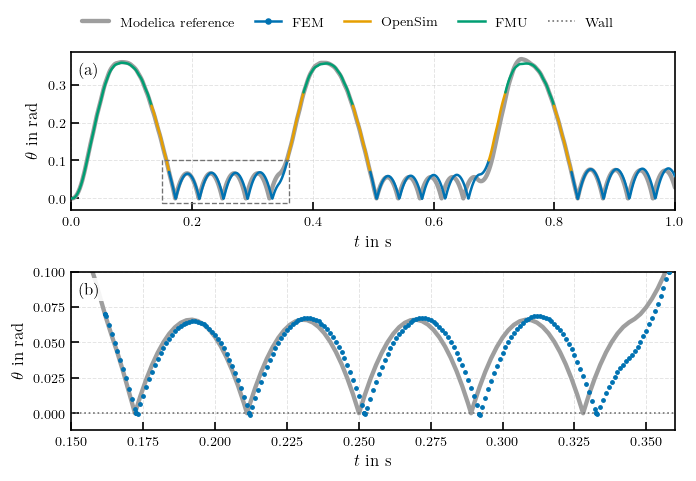

In [29]:
# F3 - (a) the whole horizon, (b) the first contact cluster. One legend above
# the figure, two x axes because the panels cover different spans.
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from plot_setup import HANDOVER_STYLE, legend_above, panel_labels

fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(FULL_WIDTH, 0.64 * FULL_WIDTH))

# Panel (b)'s y range, fitted to the bounce envelope inside its window, so the
# impacts fill the axes and the scaling never answers to data outside them.
inside = (fig_rep["t"] >= F3B_WINDOW[0]) & (fig_rep["t"] <= F3B_WINDOW[1])
top = float(np.max(fig_rep["theta"][inside])) if inside.any() else 0.05
F3B_YLIM = (-0.08 * top, 0.1)

# --- (a) the whole horizon ---------------------------------------------------
ax_a.plot(fig_ref["time"], fig_ref["theta"], **REFERENCE_STYLE)
for mode, t_seg, y_seg in mode_segments(fig_rep["t"], fig_rep["theta"],
                                        fig_rep["intervals"]):
    ax_a.plot(t_seg, y_seg, color=MODEL_COLORS[mode], linewidth=1.5,
              solid_capstyle="round", zorder=3)
# The window panel (b) shows, drawn at exactly the limits (b) uses.
ax_a.add_patch(Rectangle(
    (F3B_WINDOW[0], F3B_YLIM[0]), F3B_WINDOW[1] - F3B_WINDOW[0],
    F3B_YLIM[1] - F3B_YLIM[0], fill=False, zorder=4,
    edgecolor=HANDOVER_STYLE["color"], linestyle=HANDOVER_STYLE["linestyle"],
    linewidth=HANDOVER_STYLE["linewidth"]))
ax_a.set_xlim(SCENARIO.t0, SCENARIO.t_end)

# --- (b) the first contact cluster, FEM samples only -------------------------
ax_b.plot(fig_ref["time"], fig_ref["theta"], **REFERENCE_STYLE)
fem_intervals = [iv for iv in fig_rep["intervals"] if iv[2] == "FEM"]
for mode, t_seg, y_seg in mode_segments(fig_rep["t"], fig_rep["theta"],
                                        fem_intervals):
    ax_b.plot(t_seg, y_seg, color=MODEL_COLORS["FEM"], linestyle="None",
              marker="o", markersize=2, zorder=3)
ax_b.axhline(0.0, **WALL_STYLE)
ax_b.set_xlim(*F3B_WINDOW)
ax_b.set_ylim(*F3B_YLIM)

for ax in (ax_a, ax_b):
    ax.set_xlabel(r"$t$ in \si{\second}")
    ax.set_ylabel(r"$\theta$ in \si{\radian}")
    ax.grid(True, **GRID_STYLE)
panel_labels((ax_a, ax_b))

# One legend for both panels. FEM is a line in (a) and a marked sample in (b),
# so its entry carries both glyphs rather than naming one of them.
handles = [
    Line2D([], [], label="Modelica reference", **REFERENCE_STYLE),
    Line2D([], [], color=MODEL_COLORS["FEM"], linewidth=1.5, marker="o",
           markersize=3, label="FEM"),
    Line2D([], [], color=MODEL_COLORS["OpenSim"], linewidth=1.5, label="OpenSim"),
    Line2D([], [], color=MODEL_COLORS["FMU"], linewidth=1.5, label="FMU"),
    Line2D([], [], label="Wall", **WALL_STYLE),
]
fig.tight_layout()
legend_above(fig, handles=handles, ncol=5)

fig.savefig(OUT_DIR / f"F3_trajectory{'' if CAMPAIGN else '.smoke'}.pdf",
            bbox_inches="tight")
plt.show()


## F3d, F3e - the deformable model

**F3d, the mesh.** The reference configuration of the FEM pendulum and the wall,
with the four named boundaries the model applies its conditions on. It is a
model artifact under figure_style.md section 2: it pictures the object of
study, and the caption states the configuration because no record stands
behind the geometry itself.

**F3e, the field at the two instants that matter.** (a) the peak of the first
impact, zoomed on the contact, with both bodies carrying stress. (b) the
outgoing state of the handover that discarded the most strain energy, with the
wall drawn without its field, because `FEMPendulum.strain_energy` integrates
over the pendulum only. Each panel has its own colour scale and unit, and the
white marker is its peak. Geometry is drawn in the current configuration at
displacement scale one.

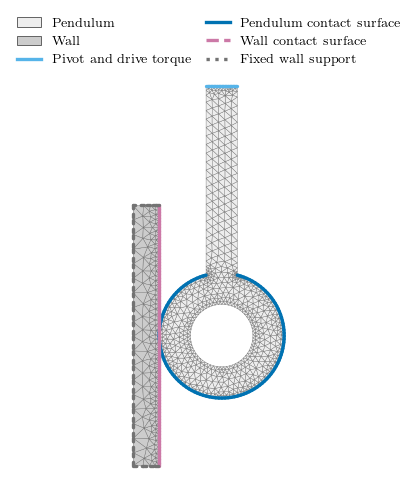

In [24]:
from fem_figures import draw_mesh, draw_stress

fig = draw_mesh(fem_geometry)
fig.savefig(OUT_DIR / f"F3d_fem_mesh{'' if CAMPAIGN else '.smoke'}.pdf",
            bbox_inches="tight")
plt.show()


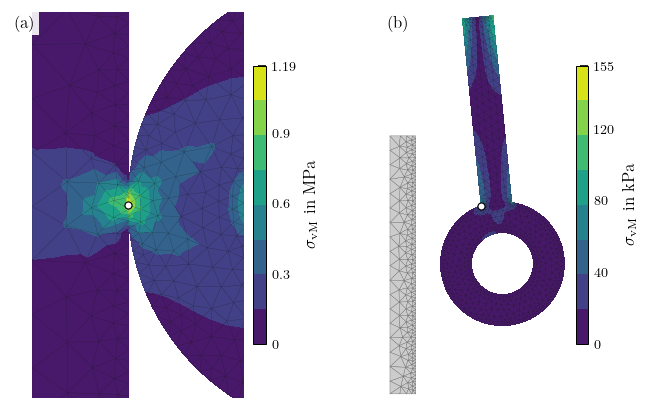

In [25]:
# Half width and half height of the impact zoom, in m, centred on the peak.
# Sized against GeometryParameters: r_head = 0.06 and wall_len_x = 0.025, so the
# window shows the head's curvature and the full wall thickness.
F3E_ZOOM_M = (0.030, 0.050)

fig = draw_stress(fem_geometry, fem_frames, zoom=F3E_ZOOM_M)
fig.savefig(OUT_DIR / f"F3e_fem_stress{'' if CAMPAIGN else '.smoke'}.pdf",
            bbox_inches="tight")
plt.show()


## Reading the result

**The enforced columns are a contract check, not a quality measure.** They cannot
show a violation in a run that completed, because the transaction would have
rolled back instead.

**The unenforced columns are the result.** `d_alpha` and `elastic_lost` are what
the canonical interface cannot carry: acceleration is not part of it, and the
strain energy in the FEM state has no counterpart in a rigid model. That loss is
by design, and this table is where its size is stated.

**Placement is off-grid by construction.** Read `min off_grid` against the macro
step: the switches sit strictly between communication points, which is what
separates this from switching on the grid.

The trajectory error against the monolithic reference is *not* a placement
measurement — the reference never switches, so it mixes model mismatch with
placement. `05_placement.ipynb` isolates placement against a refined reference of
the same configuration.

In [ ]:
ct = np.asarray(contact_times, float)
rt = np.asarray(ref_contact_times, float)
print(f"min spacing located: {np.diff(ct).min():.3e} s   reference: {np.diff(rt).min():.3e} s")
used = set()
for i, t in enumerate(ct):
    j = int(np.argmin(np.abs(rt - t)))
    extra = j in used
    used.add(j)
    gap = t - ct[i - 1] if i else float("nan")
    th = np.interp(t, t_plant, theta_plant)
    print(f"{i:2d}  {t:.8f}  ref[{j:2d}] {rt[j]:.8f}  d={t - rt[j]:+.3e}  "
          f"gap_prev={gap:.3e}  theta={th:+.2e}{'   <-- extra' if extra else ''}")
print("reference contacts with no match:", sorted(set(range(len(rt))) - used))
